In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

import numpy as np
import matplotlib.pyplot as plt

import pickle
import json
import sys
sys.path.append("../../../")

from src.context_aware.config import ModelConfig, TrainingConfig, MetaConfig
from src.dataset_manager import DatasetReader, DatasetConvertor
from src.context_aware.preprocessing import PreprocessingDataset

In [2]:
configPath = "../../config/combined_flows_forward_20.json"
rawDatasetFolder = "../../../data/raw"
dpdrDatasetFolder = "../../../data/processed/dpdr"

In [3]:
taskIndexsList = [0, 1, 2]
readFileIndexsList = [0, 1, 2, 3, 4,5,6,7,8,9,10]

datasetReader = DatasetReader()

for task in taskIndexsList:
    for file in readFileIndexsList:
        datasetReader.readRawDataset(f"{rawDatasetFolder}/Task{task}/exp{file}/motion.txt", task, file)

dfs = datasetReader.getDataFrame(randomFlag=True)
dfs.head(5)


,Time,ThumbX,ThumbY,ThumbZ,ThumbForce,IndexX,IndexY,IndexZ,IndexForce,MiddleX,...,CenterZ,cube0X,cube0Y,cube0Z,cube1X,cube1Y,cube1Z,cube2X,cube2Y,cube2Z
0,0.0000,0.243081,0.989688,-0.168696,NaN,0.259059,0.988845,-0.281148,0.881110,0.205538,...,-0.211362,0.464,0.952,-0.603,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0133,0.244122,0.990840,-0.170084,0.794986,0.259376,0.990519,-0.282639,0.846722,0.206235,...,-0.211988,0.464,0.952,-0.603,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0267,0.244589,0.990733,-0.170836,0.754080,0.259637,0.990638,-0.283419,0.807611,0.206722,...,-0.212523,0.464,0.952,-0.603,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0277,0.244104,0.989878,-0.171358,0.754080,0.259152,0.989783,-0.283941,0.807611,0.206236,...,-0.213044,0.464,0.952,-0.603,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0410,0.244403,0.990571,-0.171294,0.719665,0.259442,0.989970,-0.283876,0.771794,0.206700,...,-0.213292,0.464,0.952,-0.603,NaN,NaN,NaN,NaN,NaN,NaN


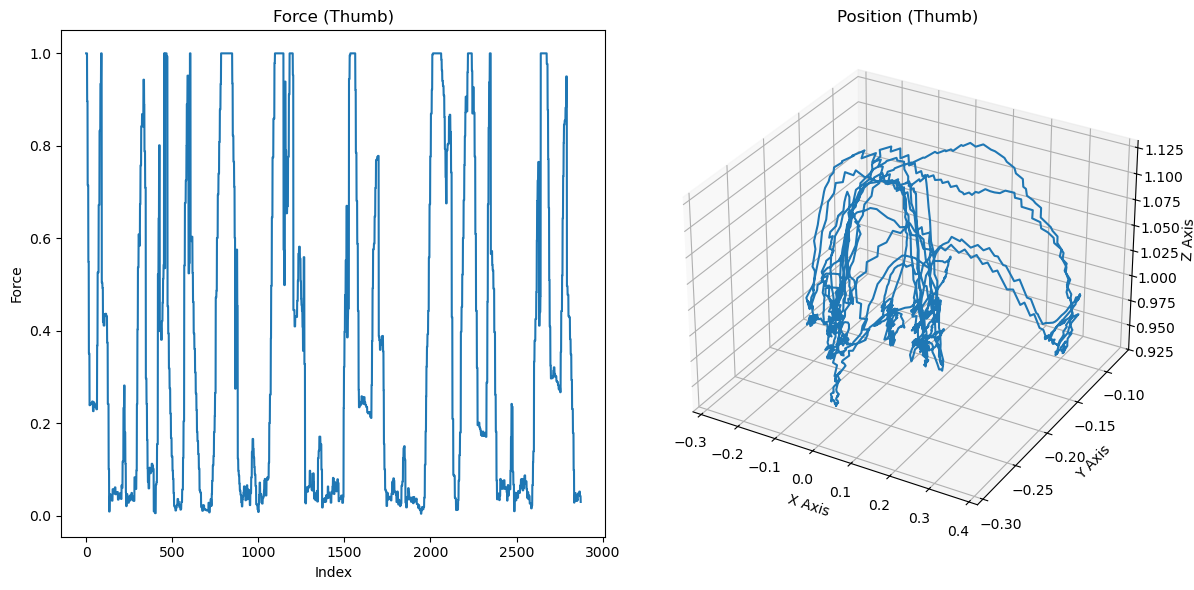

In [4]:
datasetReader.visualization(task_idx=0, exp_idx=10, fingerName="Thumb", idxsObv=10000)

In [10]:
with open(configPath, "r") as f:
    config = json.load(f)

dfs = datasetReader.getDataFrame(randomFlag=False)
datasetConverter = DatasetConvertor(dfs)

datasetConverter.addDataUnit(config)
dataUnit = datasetConverter.getDataUnit(config.get("NAME"))

In [11]:
dataUnit.display()

========= Data Unit Summary =========
  Name:                combined_flows_forward_20
  Length Window:        20
  Sampling Interval Ts: 0.01
  Data Length:          104067
  Context Dimension:    12
  Compression Rate:     0.2298
